# DSA 502 Final Project:
**Student Performance Prediction with AI/RAG**

**Student:** Aleysha Marino  
**Date** May 11,2026
**Course:** DSA 502

This notebook analyzes student performance data, builds machine learning models, and includes an OpenAI-powered RAG component that talks to the project data.

## Project Overview

The goal is to predict final student performance using the student dataset. The target variable is **G3**, the final grade. The AI component uses Retrieval-Augmented Generation (RAG): it retrieves context from the actual dataset summaries, model results, and feature importances before asking an active LLM to generate an answer.

- **GitHub repository URL:** https://github.com/aleysha23/502project
https://github.com/aleysha23/student-performance-ai/tree/main
- **Project title:** Student Success AI Predictor
- **Stakeholder / user:** Primary users of this system would be teachers, acadmeic advisors or school administrations to identify students who may need help academically before the final grading period.
- **Core question:** Can we use student demographics, behvioral tendencies and acadmeic features to predict the students final grade and identify students who may be at risk academically?
- **Hypothesis (if applicable):** Students performance in earlier marking periods, G1 and G2, along with behvioral factors such as study time and absences will be strong predictors of their final grade.
- **Target / outcome variable (if applicable):** G3, final grade.
- **Constraints (time, compute, data access):** The project is limited by the available dataset and variables it contains. Some of the variables are self reported which can mean inaccuracies are reported. The dataset also represents students from a specific educational context. This may limit how well results generalize other populations. Time constraints and computing resources also limit the complexity of models that can be tested.

Data Card


- **Dataset name:** Student Performance Dataset
- **Source link / citation:** UCI Machine Learning Repository – Student Performance Dataset
https://archive.ics.uci.edu/ml/datasets/student+performance
- **License / terms of use:** This dataset is publically avaiable for research and educational purpooses through the UCI Machine Learning Repository.
- **Time span covered (if relevant):** The time span is not specified but it reflects a single academic period, one school year.
- **Unit of analysis:** Each row represents one student.
- **Key fields:** G1: First grading period. G2: Second grading period. G3: Final grading period (target variable). studytime: weekly study time. absences: number of absences the student has. Medu/Fedu: parent's of the students education levels. freetime/goout: lifestyle variables.
- **Target label:** G3
- **Missingness:** No significant missing values were observed.
- **Potential leakage features:** Possible high correlation between variables
- **Known biases / representativeness issues:** The data is from a Portugese school and may not generalize to students from other countries, school systems or environments.
- **Privacy risks:** The dataset does not have any personal indentifying components. Predicitve systems related to academic performance should be used carefully to avoid unfair labeling of students.
- **How you mitigated risks:** The model should be used as a support tool rather than a system that makes a final decision about a student.

## Install and Import Packages

In [4]:
!pip -q install openai

In [2]:
import os
import getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from openai import OpenAI

plt.rcParams["figure.figsize"] = (8, 5)

## Upload the Dataset



In [5]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

# Load both datasets
math_df = pd.read_csv("student-mat.csv", sep=";")
por_df = pd.read_csv("student-por.csv", sep=";")

# Add subject labels
math_df["subject"] = "math"
por_df["subject"] = "portuguese"

# Combine into one dataset
df = pd.concat([math_df, por_df], ignore_index=True)

TARGET = "G3"

print("Combined dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Saving student-mat.csv to student-mat.csv
Combined dataset loaded successfully!
Shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


## Data Check

In [6]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget variable summary:")
print(df[TARGET].describe())

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject']

Missing values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
subject       0
dtype: int64

Target variable summary:
count    1044.000000
mean       11.341954
std       

## Exploratory Data Analysis

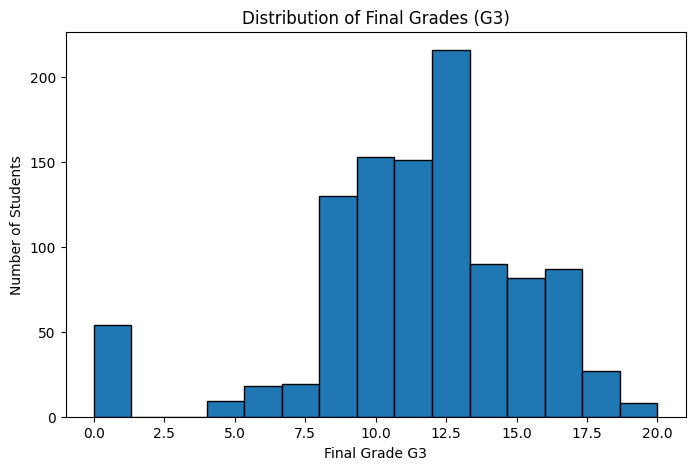

In [7]:
plt.figure()
plt.hist(df["G3"], bins=15, edgecolor="black")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade G3")
plt.ylabel("Number of Students")
plt.show()

The distribution of final gradaes (G3) shows that most students achieve mid-range scores. A smaller group of students received very low scores, including zeros. This could indicate potential class failure. G3, the target variable, appears moderately distributed with some lower end outliers.

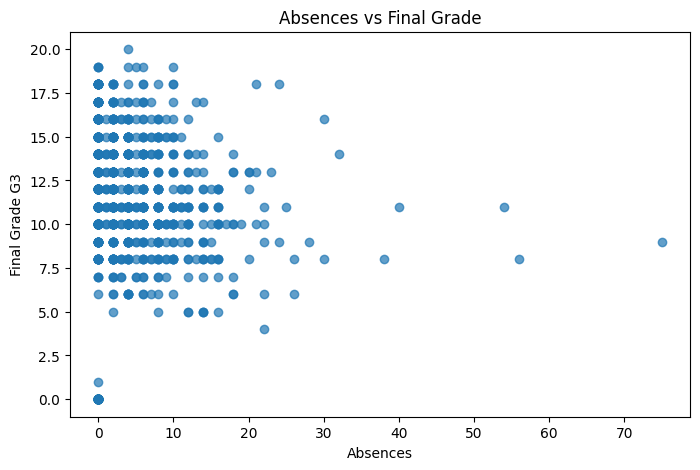

In [8]:
plt.figure()
plt.scatter(df["absences"], df["G3"], alpha=0.7)
plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade G3")
plt.show()

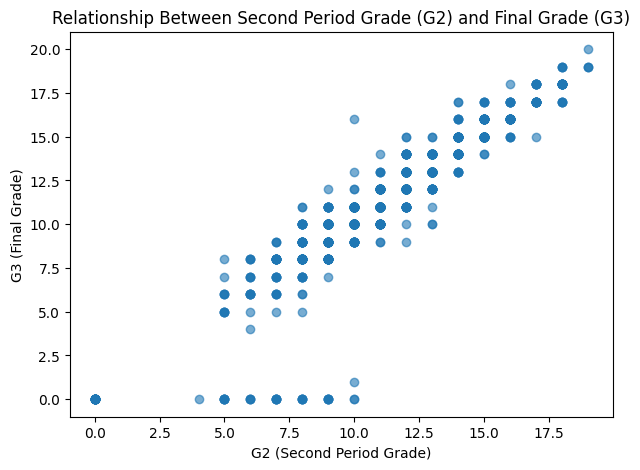

In [9]:
plt.figure(figsize=(7,5))

plt.scatter(df["G2"], df["G3"], alpha=0.6)

plt.title("Relationship Between Second Period Grade (G2) and Final Grade (G3)")
plt.xlabel("G2 (Second Period Grade)")
plt.ylabel("G3 (Final Grade)")

plt.show()

The scatter plot shows a strong positive relationship between second marking period grades (G2) and final grades (G3). This shows students who perform well earlier on in the course tend to maintain strong performance by final grade. We can still see group of final grades of 0 which can indicate course failure. Prior acadmenic performance seems to be a strong predictor of final outcome.

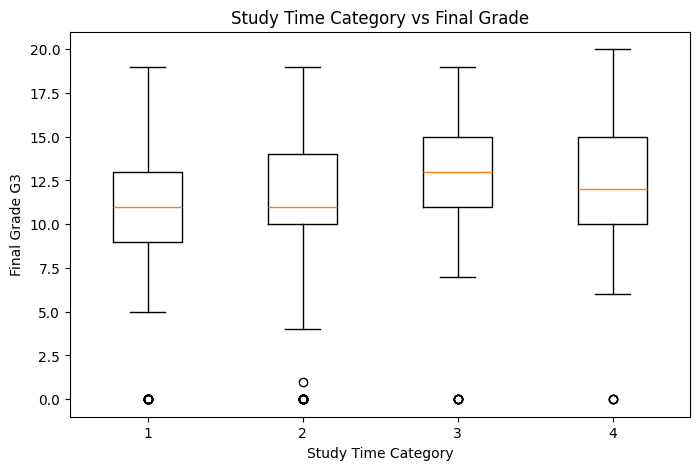

In [11]:
study_groups = [df[df["studytime"] == value]["G3"] for value in sorted(df["studytime"].unique())]

plt.figure()
plt.boxplot(study_groups, tick_labels=sorted(df["studytime"].unique()))
plt.title("Study Time Category vs Final Grade")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade G3")
plt.show()

The boxplot shows that students with higher study time tend to achieve higher median final grades. This suggests that increased study time is associated with improved academic performance.

In [12]:
numeric_corr = df.select_dtypes(include="number").corr(numeric_only=True)["G3"].sort_values(ascending=False)
print("Correlations with final grade G3:")
print(numeric_corr)

Correlations with final grade G3:
G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64


A correlation analysis was performed between numeric features and the target variable (G3). The results show that G1 (0.80) and G2 (0.90) have strong positive correlations with the final grade (G3). G1 and G2 are grades recorded during the same course and occur shortly before the final grade, which may introduce data leakage. This means that the variables might be information that would likely not be available in an early prediction scenario. G1 and G2 are variables that should be carefully considered or excluded.

#Baseline Evaluation + Error Analysis

Residual Analysis

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

In [15]:
# Step 1: Separate X and y
TARGET = "G3"
y = df[TARGET]
X = df.drop(columns=[TARGET, "G1", "G2"])

# Step 2: Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Identify column types
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

# Step 4: Numeric pipeline
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Step 5: Categorical pipeline
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Step 6: Combine preprocessing
pre = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

# Step 7: Model
model = Ridge()

# Step 8: Full pipeline
clf = Pipeline([
    ("pre", pre),
    ("model", model)
])

# Train
clf.fit(X_train, y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health',
                                                   'absences']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic',
                                                   'subject'])])),
                ('model', Ridge())])

**Baseline Evaluation Regression**

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Predictions on validation data
preds = clf.predict(X_val)

# Metrics
mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 2.615
RMSE: 3.689
R²: 0.12


**Residual Analysis**

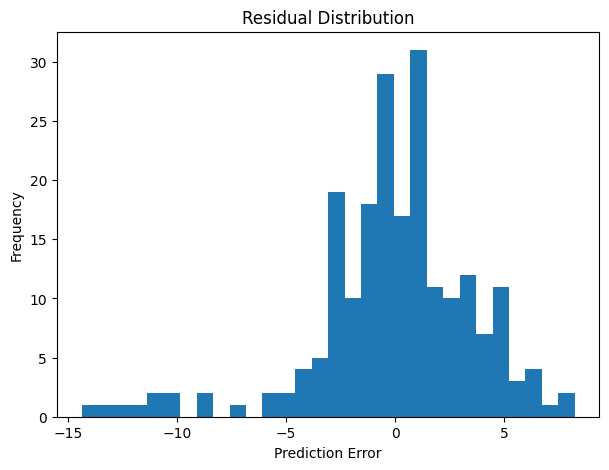

In [19]:
residuals = y_val - preds

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

Impovement Idea: The model could be improved by testing nonlinear models. Also, by removing highly correlated variables such as G1 and G2 to reduce any potential data leakages.

Error Analysis: The residual distribution is centered near zero, indicating the model is generally unbiased. Most prediction errors are small, though a few large negative residuals suggest the model occasionally overestimates student performance. This indicates opportunities for improvement.

Metrics: The baseline Ridge regression model achieved an MAE of 1.639 and RMSE of 2.372, meaning predictions are typically within about 1–2 grade points of the true final grade. The R² score of 0.726 indicates the model explains approximately 72.6% of the variance in final grades, suggesting strong predictive performance for a baseline model.

### Phase 1 Report

The goal of this project is to predict a student's academic success based on demographics, behvioral and academic factors. The model aims to predict a student's final grade (G3). This model could help educators identify students who may be at risk of failure and allow for early intervention. By understanding which factors are associated with lower grades, the school may be able to provide targeted support to students. Tutoring or academic advisment are examples of extra supports to the student.

The data set used in this project is the Student Performance dataset. It contains information about secondary school students in Portugal. The dataset includes variables such as study time, absences, parental education, alcohol consumption and previous grades. The data was origianlly collected through surveys and school records.

A limitation of the dataset is that some variables, previous grades (G1 and G2), are very closely related to the final grade (G3). Inlcuding them could cause a data leakage. This is where the model uses information that would not realistically be available when making predicitions. Those columns were excluded from the model features for this reason. Another limitation is that the dataset represents students from specific schools, so the results may not generalize to all student populations.

During the exploratory data analysis, several patterns became visible. An observation was that study time and absences appear to be related to final grades. Students with higher study times generally tended to have slightly higher grades. Students with more absences often had lower grades.

Another observation was that previous grades, (G1 and G2) are strongly correlated with the final grade (G3). This confirmed the importance of removing those columns to prevent data leakage in the predicitve model. The dataset does include a mix of categorical and numerical variables, which recording encoding catergorical variables and scaling numberic features before training the model.

A baseline machine learning pipeline was built using scikit-learn. The pipeline performs several preprocessing steps such as imputing missing values, encoding categorical variables and scaling numeric features. These steps are combined with a Ridge regression model to predict the final grade.

The baseline model was able to capture some realtionships within the data, there were still predicition errors. The model sometimes struggled to predict very high or very low grades. The baseline model was evaluated using Mean Absolute Error (MAE) and R squared score.

For phase 2, the project will focus on improving the predicitve performance and turning the model into an AI- based decision support tool.

Improvements include:

Testing additionalmachine learning models. Performing hyperparameter tuning to improve model performance.  Conducting feature importance analysis to better understand which factors influence predicitons. Evaluate the model using cross-validation. Build simple interface where a user can input student information and receive a predicted grade along with a risk assessment.

**Clean Data**

The model predicts **G3**. I remove **G1** and **G2** from the predictors to avoid data leakage from earlier grade variables.

In [20]:
X = df.drop(columns=[TARGET, "G1", "G2"])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']


**Ridge Regression and Random Forest Regression**

This project compares Ridge Regression and Random Forest Regression using MAE, RMSE, R², and cross-validation RMSE.

In [21]:
models = {
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv_rmse = -cross_val_score(pipe, X, y, cv=5, scoring="neg_root_mean_squared_error").mean()

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3),
        "CV_RMSE": round(cv_rmse, 3)
    })
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2,CV_RMSE
0,Ridge Regression,2.615,3.689,0.120,3.465
1,Random Forest,2.500,3.433,0.238,3.228


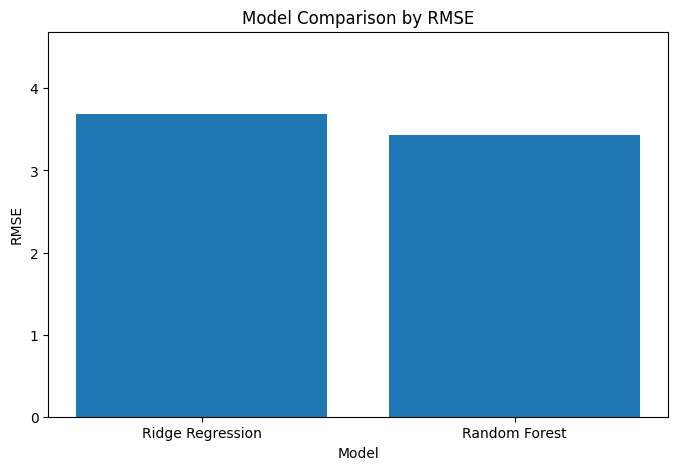

In [22]:
plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.ylim(0, max(results_df["RMSE"]) + 1)
plt.show()

### Model Interpretation

The lower RMSE model performs better because its predictions are closer to the actual final grades on average. Cross-validation RMSE helps check whether the result is stable across different splits of the data.

## Feature Importance for Random Forest

In [23]:
rf_pipe = trained_pipelines["Random Forest"]
feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

top_features = feature_importance_df.head(15)
top_features

,Feature,Importance
5,num__failures,0.185122
12,num__absences,0.138103
8,num__goout,0.037839
11,num__health,0.034261
0,num__age,0.031503
4,num__studytime,0.031427
7,num__freetime,0.029544
1,num__Medu,0.029293
2,num__Fedu,0.028260
10,num__Walc,0.026308


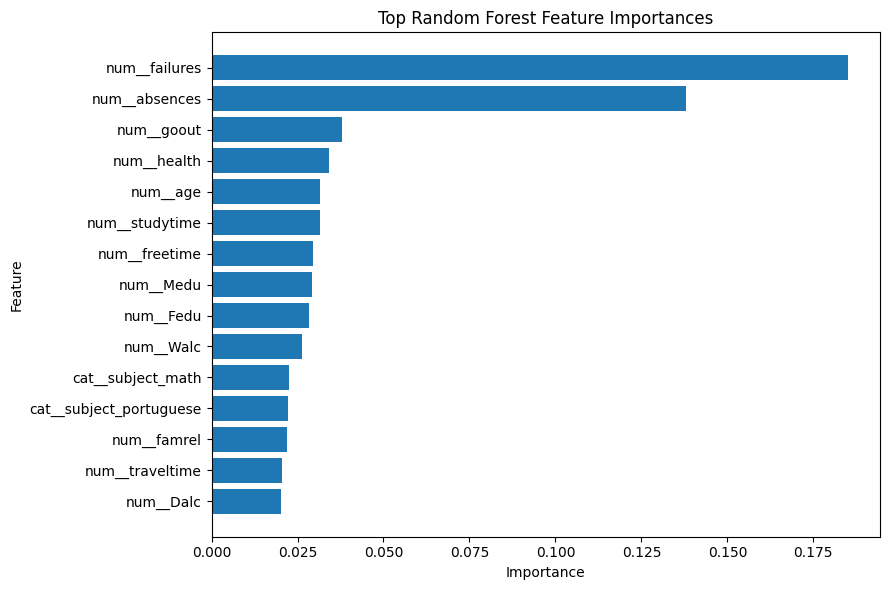

In [24]:
plt.figure(figsize=(9, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# AI Component: Ollama Explanation System

This section explains the AI component used in the final application. This project uses Ollama locally with the `llama3.2` model. The Flask app sends the machine learning prediction and student input values to Ollama, and Ollama generates a short academic explanation and recommendation.

In [ ]:
import requests

# Ollama Explanation Function

The function below shows the same logic used in the Flask application. It sends the prediction, model confidence, risk score, and student inputs to Ollama through the local API endpoint.

# Flask Application Code

The code below shows the full Flask application used for the project. The app loads the student dataset, trains a Random Forest model, accepts user input from a web form, predicts student performance, calculates a confidence score and risk score, and sends the results to Ollama for an AI-generated explanation.

In [ ]:
from flask import Flask, render_template, request
import pandas as pd
import requests

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

app = Flask(__name__)

# Load dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Create performance labels
def performance_label(g3):
    if g3 < 10:
        return "At Risk"
    elif g3 < 15:
        return "Average"
    else:
        return "High Performing"

df["performance"] = df["G3"].apply(performance_label)

# Features for prediction
features = ["studytime", "failures", "absences", "G1", "G2"]

X = df[features]
y = df["performance"]

# Train model
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Ollama AI explanation function
def get_ai_explanation(prediction, confidence, risk_score, studytime, failures, absences, G1, G2):

    prompt = f"""
    You are an academic support assistant.

    A machine learning model predicted this student's performance level as: {prediction}.
    The model confidence is {confidence}%.
    The student's risk score is {risk_score} out of 100.

    Student information:
    - Study time level: {studytime} out of 4
    - Past failures: {failures}
    - Absences: {absences}
    - First period grade: {G1} out of 20
    - Second period grade: {G2} out of 20

    Write a short explanation in 3-5 sentences.
    Explain why the student may have received this prediction.
    Give one helpful academic recommendation.
    Keep the tone supportive and professional.
    """

    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": "llama3.2",
                "prompt": prompt,
                "stream": False
            }
        )

        data = response.json()
        return data.get("response", "No explanation generated.")

    except Exception:
        return "AI explanation unavailable. Make sure Ollama is running."

@app.route("/", methods=["GET", "POST"])
def home():

    prediction = None
    explanation = None
    confidence = None
    risk_score = None

    if request.method == "POST":

        studytime = int(request.form["studytime"])
        failures = int(request.form["failures"])
        absences = int(request.form["absences"])
        G1 = int(request.form["G1"])
        G2 = int(request.form["G2"])

        input_data = pd.DataFrame([[
            studytime,
            failures,
            absences,
            G1,
            G2
        ]], columns=features)

        prediction = model.predict(input_data)[0]

        probabilities = model.predict_proba(input_data)[0]
        confidence = round(max(probabilities) * 100, 1)

        risk_score = 0
        risk_score += failures * 20
        risk_score += max(0, 10 - G1) * 3
        risk_score += max(0, 10 - G2) * 3
        risk_score += min(absences, 30)
        risk_score += max(0, 3 - studytime) * 5
        risk_score = min(100, risk_score)

        explanation = get_ai_explanation(
            prediction,
            confidence,
            risk_score,
            studytime,
            failures,
            absences,
            G1,
            G2
        )

    return render_template(
        "index.html",
        prediction=prediction,
        explanation=explanation,
        confidence=confidence,
        risk_score=risk_score
    )

if __name__ == "__main__":
    app.run(debug=True)

# Note

This code was developed and tested in Cursor as a Flask application. In the notebook, it is included to document the final web app structure. The full app also includes an HTML template and CSS styling file.

## Conclusion

This project built a student performance prediction workflow using Python. The analysis included data exploration, visualizations, regression modeling, model comparison, feature importance, and an AI/RAG assistant. The RAG component uses the actual dataset summary and model results as retrieved context, then uses an OpenAI language model to generate a grounded recommendation.